# Autoestudio 2 - Divide y conquista

Al finalizar este autoestudio debe adquirir conocimiento para:

1. Entender en que consiste la estrategia de solucion de divide y conquista.
1. Diseñar soluciones a problemas usando la estrategia de divide y conquista.
1. Resolver ecuaciones de recurrencia simples con el metodo maestro.

In [2]:
# @title Ingrese datos
nombre = "" # @param {"type":"string"}
carnet = 0 # @param {"type":"integer"}


## Introduccion



**Divide y conquista** es un método de solución de problemas en donde *dividimos* el problema inicial en problemas más pequeños del mismo tipo del original, resolvemos cada uno de forma independiente y luego combinamos sus soluciones para obtener la solución del problema original. El problema se *divide* siempre que no se tengan versiones del problema que sean triviales.

Estos algoritmos tendrán tiempos de ejecucion $T(n)$ de la forma
$$
T(n) = aT(n/b) + f(n)
$$
donde la division del problema genera $a$ subproblemas cada uno de ellos de tamaño $n/b$ . Cabe aclarar que $a, b \in \mathbb{N}$ son numeros naturales, y que $b > 1$.

Esto quiere decir que toma $T(n/b)$ tiempo resolver un solo subproblema de tamaño $n/b$, toma $aT(n/b)$ resolver todos los $a$ problemas y toma $f(n)$ la división y la combinación.

En detalle, el método consta de tres partes distintas, que individualmente tendran tiempos distintos de ejecucion:
1. **Divide** con tiempo $D(n)$
2. **Conquista** con tiempo $aT(n/b)$
3. **Combina** con tiempo $C(n)$

Cabe aclarar que  a,b∈N  son numeros naturales, y que  b>1 .

El tiempo de ejecucion de cualquier algoritmo de **divide y conquista** estara dado por
$$
T(n) = \begin{cases}
\Theta(1) & \text{si } n < n_0 \\
D(n) + aT(n/b) + C(n) & \text{si } n \geq n_0
\end{cases}
$$
El tiempo de ejecucion es $\Theta(1)$ para casos donde el problema se considera trivial, y su tiempo de ejecucion consta de hacer operaciones de tiempo constante, es decir, un numero constante de operaciones independientes del tamaño pequeño de $n$, por lo que el valor de $n_0$ sirve como este punto de comparacion.

## Ejemplo: Búsqueda

Consideremos primero el problema de búsqueda de un número en un arreglo ordenado:

> **Problema:** Busqueda en un arreglo ordenado
>
> **Entrada:** Un numero $k$, y una secuencia $A = \langle a_0, \ldots, a_{n-1} \rangle$ de $n$ numeros *ordenados ascendentemente*.
>
> **Salida:** Una posicion $i\in[0, n)$ tal que el elemento $a_i = k$, y $i=-1$ si el elemento no se encuentra dentro de $A$.



###Estrategia: incremental
Bajo esta especificacion, un algoritmo trivial que resuelve el problema planteado es:


In [3]:
def search(k: int, a: list[int]) -> int:
  steps = 0

  i = -1
  pos, n = 0, len(a)
  while pos < n and i == -1:
    if a[pos] == k:
      i = pos
    pos += 1

    steps += 1

  print(f"Numero de pasos tomados para k={k} y A={a[:min(26, len(a))]} -> {steps}")
  return i

In [4]:
print("i =", search(2, [1, 2, 3, 5]))
print("i =", search(5, [1, 2, 3, 5, 6, 7, 8, 9, 10]))
print("i =", search(15, [1, 2, 3, 5, 6, 7, 8, 9, 10]))
print("i =", search(1_000_000, list(range(1_000_000)))) # buscamos 10^6 en [0, 1, ..., 999999]

Numero de pasos tomados para k=2 y A=[1, 2, 3, 5] -> 2
i = 1
Numero de pasos tomados para k=5 y A=[1, 2, 3, 5, 6, 7, 8, 9, 10] -> 4
i = 3
Numero de pasos tomados para k=15 y A=[1, 2, 3, 5, 6, 7, 8, 9, 10] -> 9
i = -1
Numero de pasos tomados para k=1000000 y A=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25] -> 1000000
i = -1


Este algoritmo tomaria tiempo lineal, siendo $T(n) = \Theta(n)$. Esto significa que si nos dieran una entrada de $n=10^7$, en el peor caso tendriamos que hacer $10^7$ operaciones.

Con esta estrategia no estamos aprovechando realmente la especificacion del problema para solucionarlo de manera eficiente, particularmente con el hecho que la secuencia $A$ esta **ordenada ascendentemente**.



###Estrategia: divide y conquista
Si queremos tomar en cuenta esto, podemos buscar otra estrategia.





####Diseño
Tomando como ejemplo la siguiente instancia del problema:

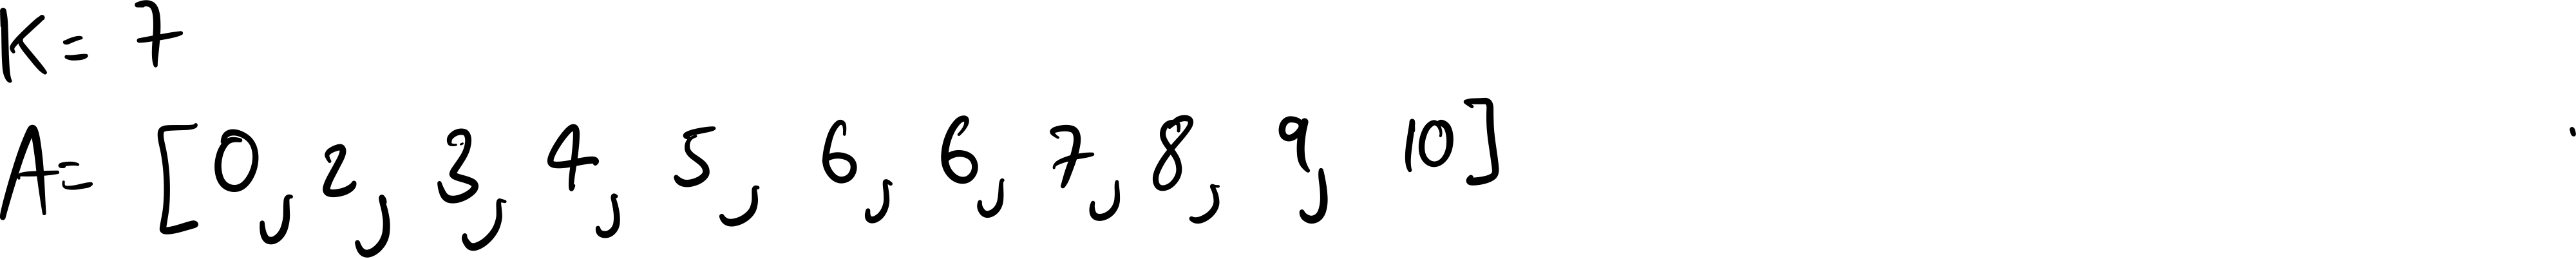

Podemos empezar por establecer un limite **inferior** $\color{blue}{\text{low}}$ y un limite **superior** $\color{blue}{\text{high}}$ en donde debe estar el elemento $k$ que buscamos (asumiendo que lo este).

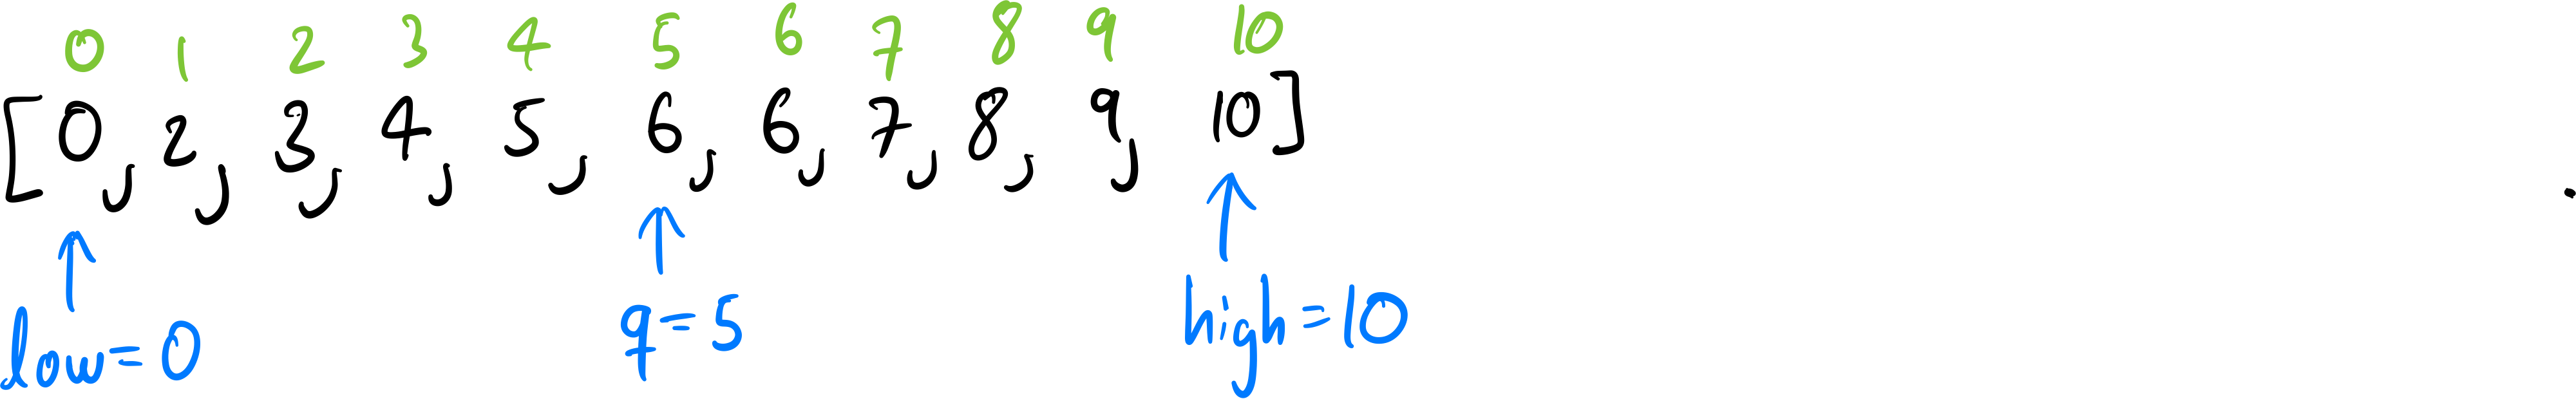

Y miramos si el elemento que buscamos esta en la *mitad* entre $\color{blue}{\text{low}}$ y $\color{blue}{\text{high}}$ usando un *pivote*, que llamaremos $\color{blue}{q}$.

$$
\color{blue}{q} = \left \lfloor \frac{\text{high} + \text{low}}{2} \right \rfloor
$$

Vemos que inicialmente $q=5$ y $a_5 = 6$ no es el elemento que buscamos $k=7$, pero vemos que $a_q < k$ ($6 < 7$), por tanto, el elemento debe estar entre $q+1$ y $\text{high}$.
Actualizamos el valor de $\text{low}$ con $q+1$. Y volvemos a calcular el valor de $q$ con la formula anterior.

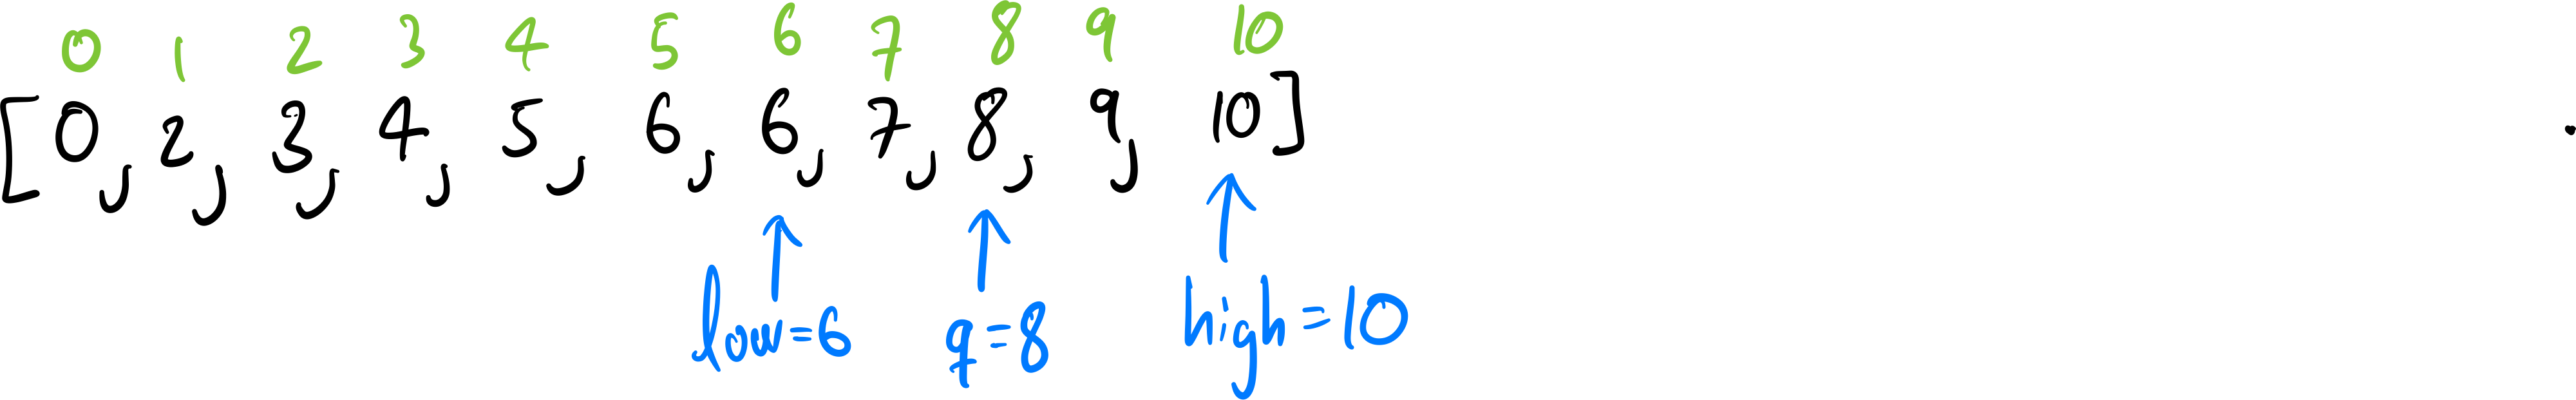

Vemos que $q=8$ y $a_8 > k$ ($8 > 7$), entonces el elemento debe estar entre $\text{low}$ y $q-1$. Actualizamos a $\text{high} = q-1$ y recalculamos el valor de $q$.

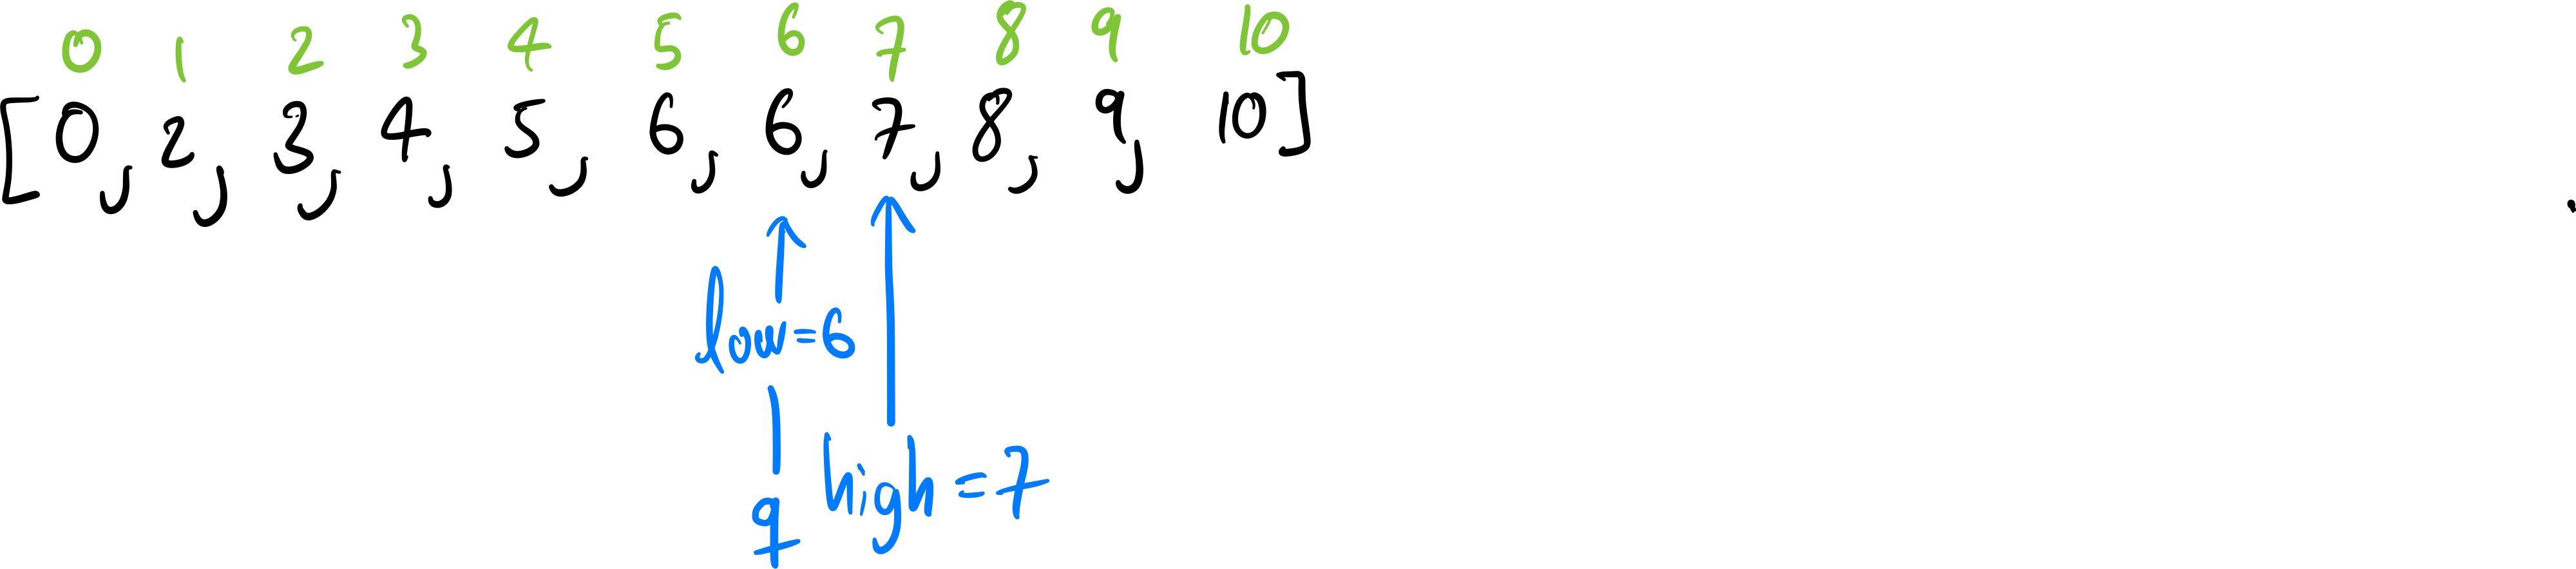

Vemos que $q=6$ y $a_6 < k$ ($6 < 7$), entonces nuestro elemento debe estar entre $q+1$ y $\text{high}$. Entonces actualizamos el valor de $\text{low} = q+1$ y recalculamos el valor de $q$.

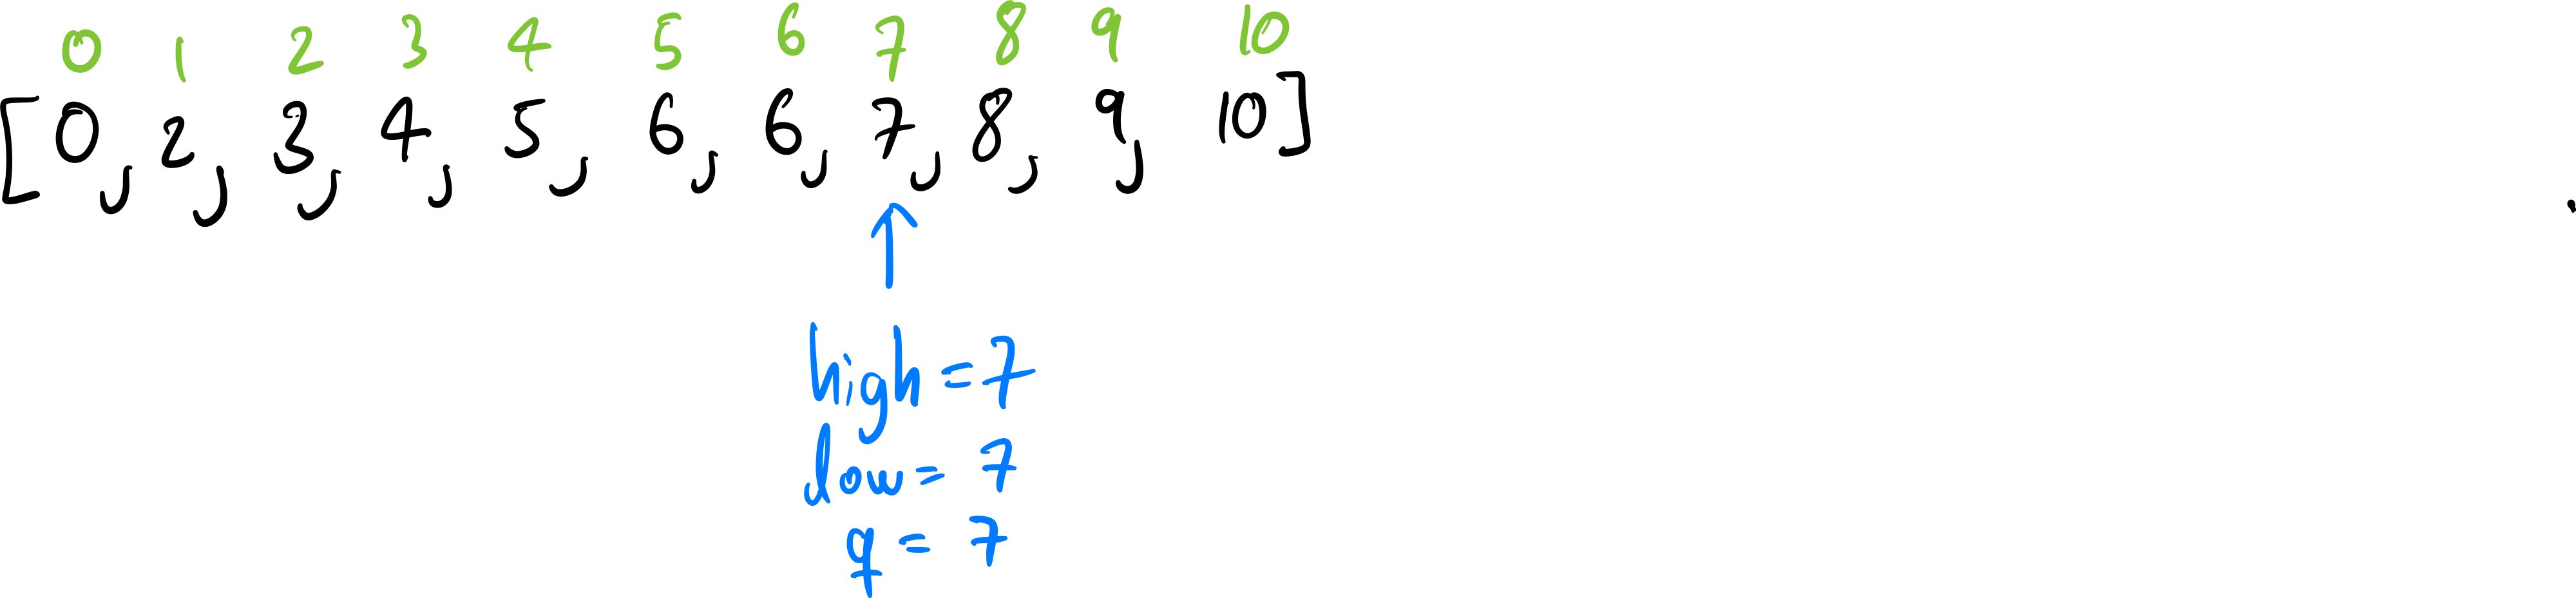

Ahora tenemos que $a_7 = k$ ($7 = 7$), por lo que encontramos nuestro elemento dentro de $A$ junto el indice que contiene su valor en $A$. Esto nos tomo apenas $\color{red}{4}$ pasos para completar.

El anterior ejemplo hace uso de la estrategia de **divide y conquista**: estamos dividiendo el problema original en partes cada vez mas pequeñas hasta que encontramos lo que buscamos en casos triviales.

Si planteamos la estrategia de solucion del ejemplo anterior como una formula recursiva, estaria dada como:
$$
f(\text{low}, \text{high}) = \begin{cases}
  -1 & \text{si } \text{low}\ > \text{high} \\
  q & \text{si } a_q = k \land \text{low} \leq \text{high} \\
  f(\text{low}, q-1) & \text{si } a_q < k \land \text{low} \leq \text{high}\\
  f(q+1, \text{high}) & \text{si } a_q > k \land \text{low} \leq \text{high}\\
\end{cases}
$$

Donde $q = \left\lfloor (\text{low} + \text{high})/2 \right\rfloor$.

####Código
Ahora pasando esto a un algoritmo que utiliza esta formula tendremos:

In [6]:
steps = 0

def bin_search(k: int, a: list[int], low: int, high: int) -> int:
  global steps
  steps += 1

  if low > high:
    return -1

  q = (high + low) // 2
  if a[q] < k: # Debemos buscar por la parte de la derecha
    return bin_search(k, a, q+1, high)
  elif a[q] > k: # Debemos buscar por la parte de la izquierda
    return bin_search(k, a, low , q-1)
  else: # a[q] == k
    return q


def search(k: int, a: list[int]) -> int:
  global steps
  steps = 0
  i = bin_search(k, a, 0, len(a)-1)
  print(f"Numero de pasos tomados para k={k} y A={a[:min(26, len(a))]} -> {steps}")
  return i

In [7]:
print("i =", search(2, [1, 2, 3, 5]))
print("i =", search(5, [1, 2, 3, 5, 6, 7, 8, 9, 10]))
print("i =", search(15, [1, 2, 3, 5, 6, 7, 8, 9, 10]))
print("i =", search(1_000_000, list(range(1_000_000)))) # buscamos 10^6 en [0, 1, ..., 999999]

Numero de pasos tomados para k=2 y A=[1, 2, 3, 5] -> 1
i = 1
Numero de pasos tomados para k=5 y A=[1, 2, 3, 5, 6, 7, 8, 9, 10] -> 4
i = 3
Numero de pasos tomados para k=15 y A=[1, 2, 3, 5, 6, 7, 8, 9, 10] -> 5
i = -1
Numero de pasos tomados para k=1000000 y A=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25] -> 21
i = -1


####Análisis

Si analizamos el tiempo de ejecucion de este algoritmo, al ser un algoritmo recursivo, la funcion va a estar dada de la forma
$$
T(n) = aT(n/b) + f(n)
$$

Ya que nosotros en cada paso de la funcion estamos dividiendo el problema en 2 partes, tenemos que $b = 2$, pero ya que solo estamos haciendo la busqueda de nuestro elemento en un solo lado de nuestro arreglo, tenemos que solo tenemos que resolve un subproblema, es decir $a=1$.

Con esto nos queda
$$
T(n) = T(n/2) + f(n)
$$

**¿Pero que es $f(n)$?** Este es el costo de tiempo de dividir y combinar.

Si notamos en nuestro algoritmo, solo estamos haciendo operaciones aritmeticas para calcular $q$, $\text{low}$ y $\text{high}$, en donde estas se presumen de tiempo constante, o bien $\Theta(1)$. Como estas son las unicas operaciones que se estan realizando tenemos entonces que:

$$
T(n) = T(n/2) + \Theta(1)
$$

----
Viendolo con los pasos caracteristicos de divide y conquista tenemos:
1. **Divide:** Divide el intervalo de busqueda usando calculos aritmeticos sobre los indices de la secuencia de entrada, por lo que es tiempo constante $\Theta(1)$.
2. **Conquista:** Resuelve un ($a=1$) solo problema de tamaño $n/2$, que contribuye $T(n/2)$ al tiempo de ejecucion.
3. **Combina:** Como solo estamos haciendo comparaciones y operaciones aritmeticas, esto toma solo $\Theta(1)$.

Quedando tambien $T(n) = \Theta(1) + T(n/2) + \Theta(1) = T(n/2) + \Theta(1)$

> **Nota**: Un algoritmo recursivo puede subdividir un problema en tamaños heterogeneos, como divisiones $\frac{2}{3}$ a $\frac{1}{3}$, por lo que si los pasos de divide y conmbina tomaran tiempo lineal $\Theta(n)$, este algoritmo nos daria una recurrencia de la forma
>
> $T(n) = T(2n/3) + T(n/3) + \Theta(n)$
>
> Cabe aclarar que calcular soluciones de este tipo de ecuaciones de recurrencia estan por fuera del alcance del curso.

Si bien tenemos la formula que describe el tiempo de ejecucion de nuestro algoritmo de divide y conquista, nos es de poca utilidad una formula de este estilo para saber realmente como se comporta nuestro algoritmo.

## $\color{blue}{Ejercicios}$

Considere la siguiente especificacion

> **Problema:** Potencia
>
> **Entrada:** Un numero $x\in\mathbb{R}$ y un numero natural $n\in\mathbb{N}$.
>
> **Salida:** El calculo de $x^n$

Y considere el siguiente algoritmo que resuelve el problema planteado:

In [8]:
def power(x: float, n: int) -> float:
  assert n >=0 and isinstance(n, int)
  assert isinstance(x, float) or isinstance(x, int)
  if n == 0:
    return 1
  elif n % 2 == 0:
    return power(x * x, n//2)
  else:
    return x * power(x * x, (n-1)//2)

In [ ]:
print(power(2, 5))

32


1. **Especifique** la ecuacion de recurrencia $T(n)$ para el algoritmo. Justifique su respuesta.

##Metodos de solucion de ecuaciones de recurrencia

Existen diferentes maneras de resolver este tipo de ecuaciones recursivas:
1. **Metodo de sustitucion**: consiste en adivinar el limite y luego usar induccion matematica para demostrar que es correcto.
2. **Metodo de arbol de recursion**: consiste en convertir la recurrencia visualmente en un arbol, cuyos nodos representan el costo incurrido en los diferentes niveles de la recursion, para finalmente hacer una sumatoria de los costos de cada nivel.
3. **Metodo maestro**: consiste en aplicar el *teorema maestro* para calcular los limites de las recurrencias que tengan la forma $T(n) = aT(n/b) + f(n)$

Nos enfocaremos unicamente en hacer la solucion de estas ecuaciones de recurrencia con el *metodo maestro*

### Metodo maestro

El metodo maestro nos es util para resolver recurrencias de la forma
$$
T(n) = aT(n/b) + f(n)
$$
donde $a > 0$ y $b > 1$ son constantes y $f(n)$ es una funcion positiva para valores suficientemente grandes de $n\in\mathbb{N}$.

El metodo maestro depende del **teorema maestro**.

---

**Teorema maestro**
Sea $a > 0$ y $b > 1$ constantes, sea $f(n)$ una funcion definida y no-negativa y sea $T(n)$ definida por la recurrencia
$$
T(n) = aT(n/b) + f(n)
$$

Sea $\epsilon > 0$, $k \geq 0$, y $c < 1$.

Entonces tenemos que $T(n)$ posee los siguientes limites asintoticos:

1. Si $f(n) = O(n^{\log_{b}{a}-\epsilon})$, entonces $T(n) = \Theta(n^{\log_{b}{a}})$
2. Si $f(n) = \Theta(n^{\log_{b}{a}} \log^{k} n)$, entonces $T(n)=\Theta(n^{\log_{b}a} \log^{k+1} n)$
3. Si $f(n) = \Omega(n^{\log_{b}{a}+\epsilon})$ y $a f(n/b) \leq c f(n)$, entonces $T(n) = \Theta(f(n))$

---

> **Nota**: Los tres casos no cubren todas las posibilidades para $f(n)$. Si no se cumplen todas las condiciones establecidas, entonces no es posible usar el metodo maestro.

### Ejemplo
Consideremos la siguiente formula
$$
T(n) = 2T(n/4) + n^2
$$
Para resolverla con el metodo maestro, primero debemos observar los parametros correspondientes con el teorema maestro, primeramente podemos reconocer lo siguiente: $a = 2$; $b = 4$; $f(n) = n^2$.

Ahora queremos encontrar cual de los tres casos corresponde nuestra funcion $f(n)$.

Una manera sencilla es por medio de calcular lo que se le denomina "funcion cuenca" (*watershed function*), que es $n^{\log_{b}a}$.

Calculandola nos da: $n^{\log_{b}a} = n^{\log_{4}2} = n^{1/2}$.

¿Como se compara esta funcion con $f(n)$?

$$
\begin{aligned}
f(n) &\stackrel{?}{=} n^{\log_{b}a}\\
n^2  &\stackrel{?}{=} n^{1/2}
\end{aligned}
$$

Como podemos ver, el exponente de nuestra funcion 'cuenca' necesita un valor positivo en el exponente para ser igual a la funcion $f(n)$, particularmente
$$
n^2 = n^{1/2+\epsilon}
$$
donde $\epsilon = 3/2$.

Con esto podemos ver que el caso mas apropiado a aplicar es el caso #3 del teorema maestro.

---

Sin embargo, existe una segunda condicion (unica para el caso #3) a verificar para saber que cumple las condiciones del teorema para poder ser aplicado, en particular es la *condicion de regularidad*.

Debemos verificar si $af(n/b) \leq c f(n)$. Para esto reemplazamos los valores correspondientes:
$$
\begin{aligned}
af(n/b) &\leq cf(n)\\
2f(n/4) &\leq cf(n)\\
2\left( \frac{n}{4} \right)^{2} &\leq c (n^2)\\
2\left( \frac{n^2}{16} \right) &\leq cn^2\\
\frac{1}{8}n^2 &\leq cn^2\\
\end{aligned}
$$

Podemos elegir un valor para la constante $c=1/8$, donde $0 < c < 1$, encontramos que cumple la condicion de regularidad.

Con esto podemos concluir que al cumplir las condiciones del caso #3 del teorema maestro, podemos finalmente concluir con que el limite asintotico de $T(n)$ es
$$
\begin{aligned}
T(n)&=\Theta(f(n))\\
&=\Theta(n^2)
\end{aligned}
$$

### $\color{blue}{Ejercicios}$

**Resuelva** las siguientes ecuaciones de recurrencia usando el metodo maestro:

1. $T(n) = 2T(n/4) + 1$
1. $T(n) = 2T(n/4) + \sqrt{n}$
1. $T(n) = 2T(n/4) + \sqrt{n}\log^{2}n$
1. $T(n) = 2T(n/4) + n$
1. $T(n) = 9T(n/3) + n$

**Bonos:**

6. $T(n) = T(2n/3) + 1$
7. $T(n) = 3T(n/4) + n\log n$
8. $T(n) = 2T(n/2) + \Theta(n)$
9. $T(n) = 8T(n/2) + \Theta(n^2)$
10. $T(n) = 7T(n/2) + \Theta(n^2)$

Esta ultima formula corresponde al algoritmo de Strassen, adicional a resolver la formula, **investigue y describa** muy brevemente en que consiste este algoritmo.

## $\color{blue}{BONO}$

### UVa 11057 - Exact Sum

**Link**: https://vjudge.net/problem/UVA-11057

**Tiempo limite: 3 segundos**

Peter recibio dinero de sus padres esta semana y quiere gastarlo todo en libros. Pero no lee un libro tan rapido, porque a el le gusta disfrutar cada palabra mientras lee. Haciendolo a su manera, le toma una semana leer un solo libro.

A medida que Peter recibe mas dinero cada dos semanas, el decide comprar dos libros, y los puede leer hasta que reciba mas dinero. Como el quiere gastar todo el dinero, el debe escoger dos libros cuyos precios sumados sean iguales al dinero que el tiene. Es un poco dificil encontrar estos libros, por lo que Peter pide tu ayuda para encontrarlos.

### Entrada
Cada caso de prueba empieza por $2\leq N \leq 10000$, el numero de libros disponibles. Las siguiente linea contiene $N$ enteros, representando el precio de cada libro, un libro cuesta menos que $1000001$. Luego hay otra linea con un entero $M$, representando la cantidad de dinero que Peter tiene. Hay una linea vacia entre cada caso de prueba. La entrada termina por un "end of file" (EOF).

### Salida
Para cada caso de prueba se debe imprimir el mensaje `Peter should buy books whose prices are i and j.`, donde $i$ y $j$ son los precios de los libros cuyas sumas son iguales a $M$ y $i \leq j$. Puede asumir que siempre existe una solucion, si existen multiples soluciones, imprima la solucion que minimice la diferencia entre los precios $i$ y $j$. Luego de cada caso de prueba debe imprimir una linea vacia.

### Entrada de ejemplo
```
2
40 40
80

5
10 2 6 8 4
10
```
### Salida de ejemplo
```
Peter should buy books whose prices are 40 and 40.

Peter should buy books whose prices are 4 and 6.

```

### Especificación

El problema nos especifica que queremos encontrar dos libros dentro de la lista de libros tal que el precio de ambos sumados nos de igual a la cantidad de dinero que tiene Peter, y que la diferencia de precios de ambos libros sea lo mas cercano posible.

En otras palabras,
> **Problema:** Suma exacta
>
> **Entrada:** Un arreglo de numeros $P = \langle p_1, \ldots, p_N \rangle$ y un numero $m$.
>
> **Salida:** Dos numeros $p_i$ y $p_j$ tal que $p_i + p_j = m$, tambien $p_i \leq p_j$, y donde $\mid p_i - p_j \mid$ sea minimo.



###Incremental: Diseño
La solucion trivial implicaria comparar todas las $\binom{n}{2} = \frac{n(n-1)}{2}$ posibilidades y extraer la solucion optima, pero esta solucion nos daria un tiempo de ejecucion de $T(n) = \Theta(n^2)$, esta solucion es muy costosa en terminos de tiempo, primero dado por que $2 \leq N \leq 10000$.

Si usamos la siguiente tabla como referencia, tenemos que dado el peor caso de entrada ($N = 10000$), tendriamos que un solo caso tomaria aproximadamente ~100ms. Pero esto es solo para un caso, no sabemos cuantos casos de prueba estamos recibiendo en el momento que nuestro programa se ejecuta en el juez ya que no es mencionado en el enunciado.

¿Que pasaria si se ejecutan 30 casos de prueba con tamaños cercanos al peor caso? Solo con esa entrada estariamos sobre el tiempo limite dado por el juez (*3 segundos para este problema*).

¿Podemos mejorar este tiempo?

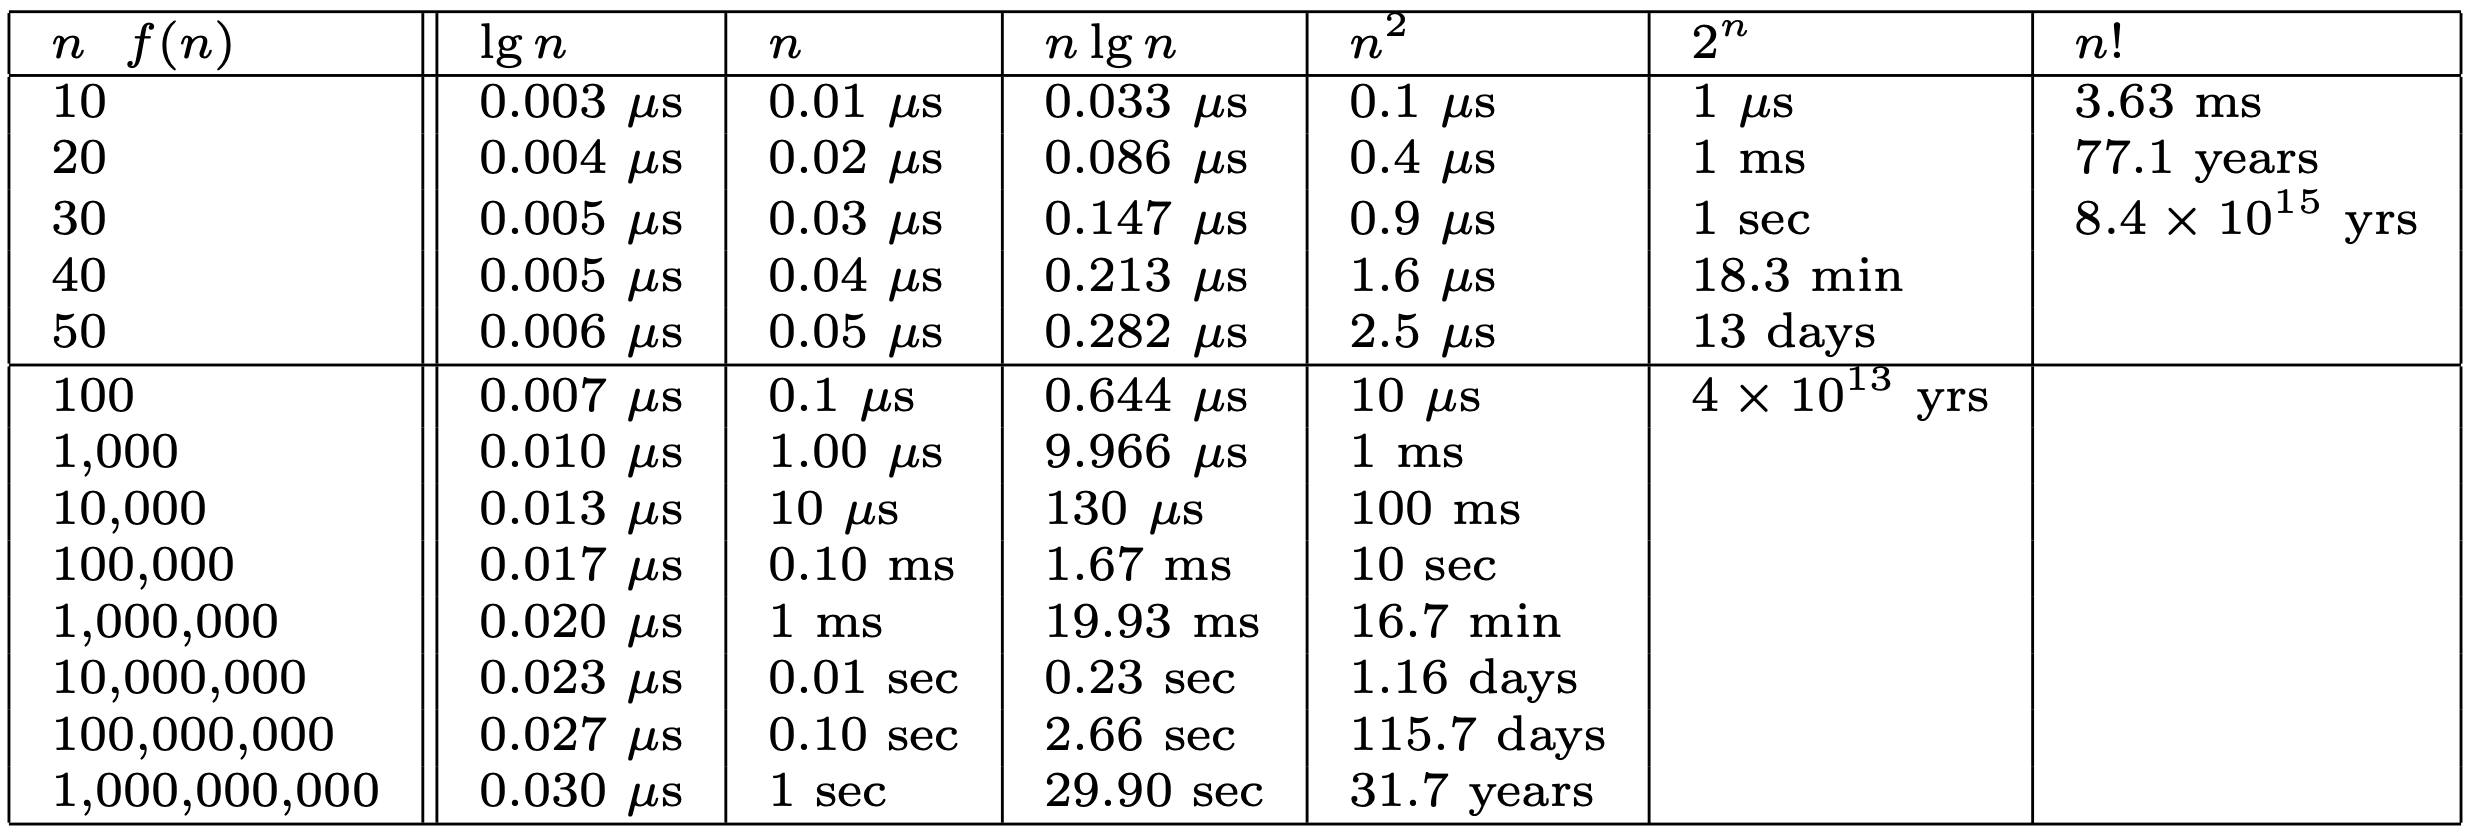

### Incremental: Código
Ahora codifiquemos la funcion `solve` que resuelve una instancia del problema la manera trivial en tiempo $T(n) = \Theta(n^2)$.

In [ ]:
def solve(p: list[int], m: int) -> tuple[int, int]:
  best_price = (0, 10**9) # Mejores precios
  price_diff = 10**9 # Diferencia de precios
  n = len(p)
  for i in range(n): # O(n)
    for j in range(i+1, n): # O(n) * O(n) = O(n^2)
      p_i, p_j = p[i], p[j]
      if p_i + p_j == m:
        # La suma de precios es igual a la cantidad de dinero 'm' de Peter
        diff = abs(p_j - p_i)
        if diff < price_diff:
          price_diff = diff
          best_price = min(p_i, p_j), max(p_i, p_j)

  return best_price


In [ ]:
print(solve([40, 40], 80))
print(solve([10, 2, 6, 8, 4], 10))

(40, 40)
(4, 6)


###Divide y conquista: Diseño
Ahora diseñemos una solucion mas eficiente usando la estrategia de divide y conquista.

Podemos preparar que nuestros datos de entrada para que esten ordenados de manera ascendente (esto en tiempo $O(n \log n)$) y que podamos realizar consultas eficientes con busqueda binaria, cada consulta costara tiempo $\Theta(\log n)$.



###Divide y conquista: Código
Primero implementemos la busqueda binaria, podemos implementarla sin necesidad de recursion:

In [ ]:
def bin_search(k: int, a: list[int]) -> int: # O(log n)
  low, high = 0, len(a) -1
  r = -1

  while low <= high and r == -1:
    q = (high + low) // 2
    if a[q] == k:
      r = q
    elif a[q] < k:
      low = q+1
    else: # a[q] > k
      high = q-1

  return r


In [ ]:
# Probemos a bin_search
print(bin_search(5, [1, 3, 5, 7, 9])) # Debe imprimir 2
print(bin_search(1, [1, 3, 5, 7, 9])) # Debe imprimir 0
print(bin_search(9, [1, 3, 5, 7, 9])) # Debe imprimir 4
print(bin_search(6, [1, 3, 5, 7, 9])) # Debe imprimir -1

2
0
4
-1


Ahora implementemos la solucion al problema con ayuda de nuestra busqueda binaria:

In [ ]:
def solve(p: list[int], m: int) -> tuple[int, int]:
  best_price = (0, 10**9) # Mejores precios
  price_diff = 10**9 # Diferencia de precios
  n = len(p)

  p.sort() # O(n log n)

  for i in range(n): # O(n)
    p_i = p[i]
    p_j = m - p_i
    # Buscamos a p_j = m - p_i dentro de los precios de los libros
    j = bin_search(p_j, p) # O(n) * O(log n) = O(n log n)

    if j != -1:
      # Si lo encontramos entonces verificamos si es mejor que lo que llevamos
      diff = abs(p_j - p_i)
      if diff < price_diff:
        price_diff = diff
        best_price = (min(p_i, p_j), max(p_i, p_j))

  return best_price

In [ ]:
print(solve([40, 40], 80))
print(solve([10, 2, 6, 8, 4], 10))

(40, 40)
(4, 6)


Ahora nuestro metodo `solve` paso de tomar tiempo $\Theta(n^2)$ a $\Theta(n \log n)$, esto significa que para el peor caso que estimula el enunciado, pasaremos de un tiempo de ~100ms a tan solo ~130us, aproximadamente un orden de magnitud menos (10x).

###A Juez
Ahora sin mucho preambulo, este siguiente codigo nos permitira leer los casos de prueba del juez virtual.

In [ ]:
def read(stdin) -> str:
  return stdin.readline().strip()

def main(stdin):
  for line in stdin:
    n = int(line.strip()) # el numero de libros
    prices = [int(i) for i in read(stdin).split()]  # precios de los libros
    m = int(read(stdin))  # el dinero que tiene peter
    read(stdin)  # leemos la linea vacia
    assert n == len(prices)

    p_i, p_j = solve(prices, m)
    assert p_i + p_j == m, "la suma de precios no es igual al dinero de peter"
    assert p_i <= p_j, "el primer valor debe ser menor o igual al segundo"

    print(f"Peter should buy books whose prices are {p_i} and {p_j}.\n")

In [ ]:
casos = """2
40 40
80

5
10 2 6 8 4
10
"""

import io
stdin = io.StringIO(casos)
main(stdin)

Peter should buy books whose prices are 40 and 40.

Peter should buy books whose prices are 4 and 6.



### $\color{blue}{Ejercicio}$

**Dirijase** al ejercicio en la pagina del juez virtual y ejecute el codigo que resuelve el ejercicio, pruebe con la solucion trivial y la optimizada. Muestre el veredicto de ambas. Explique.